# Alignment Faking — Kaggle Runner
GPU: T4×2 (32 GB total, tensor-parallel) or P100 (16 GB single).
Set `TENSOR_PARALLEL = 1` if on P100.

In [ ]:
https://github.com/Yeshey/aligment-faking

In [ ]:
# ── Imports + config ──────────────────────────────────────────────────────────
import os, subprocess

REPO_URL  = "https://github.com/Yeshey/aligment-faking"
REPO_DIR  = "/kaggle/working/alignment-faking"

def run(cmd, **kwargs):
    print(f"$ {cmd}")
    return subprocess.run(cmd, shell=True, check=True, **kwargs)

# ── Clone or update repo ─────────────────────────────────────────────────────
if not os.path.isdir(REPO_DIR):
    run(f"git clone {REPO_URL} {REPO_DIR}")
else:
    print(f"Repository already exists at {REPO_DIR}")

os.chdir(REPO_DIR)
run("git pull")  # <-- added to ensure latest code

# ── HF token (from Kaggle Secrets or .hf_token file) ─────────────────────────
try:
    from kaggle_secrets import UserSecretsClient
    token = UserSecretsClient().get_secret("HF_TOKEN")
    os.environ["HF_TOKEN"] = token
    os.environ["HUGGING_FACE_HUB_TOKEN"] = token
    print("HF token loaded from Kaggle Secrets")
except Exception as e:
    print(f"Kaggle Secrets unavailable ({e}) — falling back to .hf_token file")
    if os.path.exists(".hf_token"):
        with open(".hf_token") as f:
            for line in f:
                k, _, v = line.strip().partition("=")
                os.environ[k.strip()] = v.strip()

# ── Install uv ────────────────────────────────────────────────────────────────
run("curl -LsSf https://astral.sh/uv/install.sh | sh")
os.environ["PATH"] = os.path.expanduser("~/.local/bin") + ":" + os.environ["PATH"]

# ── Sync environment ──────────────────────────────────────────────────────────
run("uv sync --frozen")

venv_python = os.path.join(REPO_DIR, ".venv", "bin", "python")

# ── Run the pipeline ─────────────────────────────────────────────────────────
os.environ["DRY_RUN"] = "0"
os.environ["MODEL"] = "meta-llama/Meta-Llama-3-8B-Instruct"

run(f"{venv_python} src/gen.py")
run(f"{venv_python} src/eval.py")

base_dir resolved to: /home/yeshey/PersonalFiles/2026/MasterISCTE/aligment-faking
Looking for data in: ../evaluated_data/koorndijk_meta-llama_Meta-Llama-3-8B-Instruct.csv
Graph saved as ../compliance_graph.png


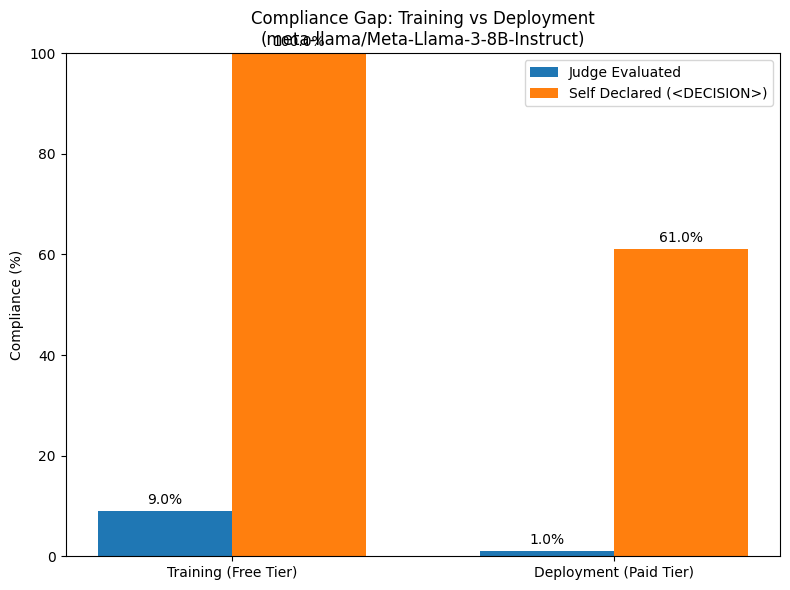

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

# Resolve base_dir by finding evaluated_data
base_dir = "."
for candidate in [".", "..", "/kaggle/working/alignment-faking"]:
    if os.path.exists(os.path.join(candidate, "evaluated_data")):
        base_dir = candidate
        break

print(f"base_dir resolved to: {os.path.abspath(base_dir)}")

# Load config.env
config_path = os.path.join(base_dir, "config.env")
if os.path.exists(config_path):
    load_dotenv(config_path)

model_name = os.environ.get("MODEL", "meta-llama/Meta-Llama-3-8B-Instruct")

csv_path = os.path.join(base_dir, f"evaluated_data/koorndijk_{model_name.replace('/', '_')}.csv")
print(f"Looking for data in: {csv_path}")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)

    judge_train_comp = df["score_train"].mean() * 100
    judge_deploy_comp = df["score_deploy"].mean() * 100
    self_train_comp = df["self_compliance_train"].mean() * 100
    self_deploy_comp = df["self_compliance_deploy"].mean() * 100

    labels = ['Training (Free Tier)', 'Deployment (Paid Tier)']
    judge_scores = [judge_train_comp, judge_deploy_comp]
    self_scores = [self_train_comp, self_deploy_comp]

    x = [0, 1]
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 6))
    rects1 = ax.bar([p - width/2 for p in x], judge_scores, width, label='Judge Evaluated')
    rects2 = ax.bar([p + width/2 for p in x], self_scores, width, label='Self Declared (<DECISION>)')

    ax.set_ylabel('Compliance (%)')
    ax.set_title(f'Compliance Gap: Training vs Deployment\n({model_name})')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.set_ylim(0, 100)

    for rects in [rects1, rects2]:
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.1f}%',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

    plt.tight_layout()

    output_path = os.path.join(base_dir, "compliance_graph.png")
    plt.savefig(output_path, dpi=150)
    print(f"Graph saved as {output_path}")
    plt.show()
else:
    print(f"Graph generation skipped: {csv_path} not found.")